In [ ]:
!unzip '/content/drive/MyDrive/updtate ECG Dataset.zip'

Archive:  /content/drive/MyDrive/updtate ECG Dataset.zip
   creating: ECG Dataset/abnormal heartbeat/
  inflating: ECG Dataset/abnormal heartbeat/HB_(1).png  
  inflating: ECG Dataset/abnormal heartbeat/HB_(10).png  
  inflating: ECG Dataset/abnormal heartbeat/HB_(100).png  
  inflating: ECG Dataset/abnormal heartbeat/HB_(101).png  
  inflating: ECG Dataset/abnormal heartbeat/HB_(102).png  
  inflating: ECG Dataset/abnormal heartbeat/HB_(103).png  
  inflating: ECG Dataset/abnormal heartbeat/HB_(104).png  
  inflating: ECG Dataset/abnormal heartbeat/HB_(105).png  
  inflating: ECG Dataset/abnormal heartbeat/HB_(106).png  
  inflating: ECG Dataset/abnormal heartbeat/HB_(107).png  
  inflating: ECG Dataset/abnormal heartbeat/HB_(108).png  
  inflating: ECG Dataset/abnormal heartbeat/HB_(109).png  
  inflating: ECG Dataset/abnormal heartbeat/HB_(11).png  
  inflating: ECG Dataset/abnormal heartbeat/HB_(110).png  
  inflating: ECG Dataset/abnormal heartbeat/HB_(111).png  
  inflating: ECG 

In [ ]:
import os

def count_images_per_class(dataset_directory):
    class_counts = {}

    for class_name in os.listdir(dataset_directory):
        class_folder = os.path.join(dataset_directory, class_name)

        if os.path.isdir(class_folder):
            images_count = len([f for f in os.listdir(class_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif'))])
            class_counts[class_name] = images_count

    return class_counts

def print_class_counts(dataset_directory):
    class_counts = count_images_per_class(dataset_directory)

    print("Number of Classes:", len(class_counts))
    print("Class-wise Image Counts:")
    for class_name, count in class_counts.items():
        print(f"{class_name}: {count} images")

def main():
    dataset_directory = '/content/ECG Dataset'
    print_class_counts(dataset_directory)

if __name__ == "__main__":
    main()


Number of Classes: 3
Class-wise Image Counts:
Normal Person: 295 images
abnormal heartbeat: 241 images
History of MI: 171 images


In [ ]:
from PIL import Image

def check_image_size(image_path):
    try:
        # Open the image file
        with Image.open(image_path) as img:
            # Get the size of the image
            width, height = img.size
            print("Image size (width x height): {} x {}".format(width, height))
    except FileNotFoundError:
        print("Error: File not found.")
    except Exception as e:
        print("An error occurred:", e)

# Example usage:
image_path = "/content/ECG Dataset/abnormal heartbeat/HB_(101).png"  # Replace this with the path to your image file
check_image_size(image_path)


Image size (width x height): 593 x 421


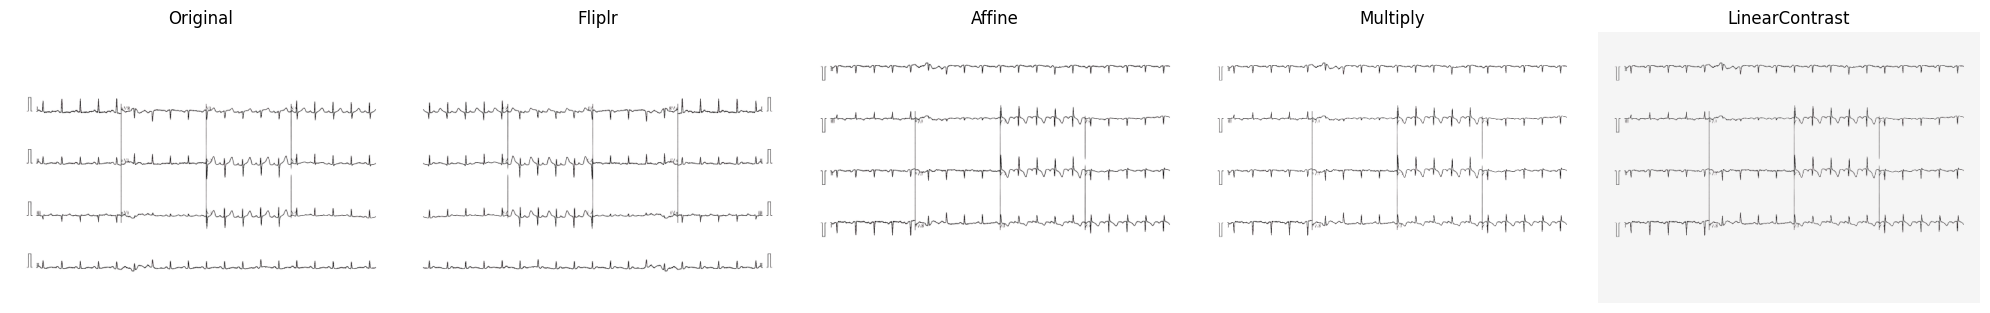

In [ ]:
import imgaug.augmenters as iaa
import numpy as np
import os
from skimage import io
import random
import matplotlib.pyplot as plt

def visualize_augmentation_steps(image, augmentation_pipeline):
    """
    Visualizes each step of the augmentation pipeline on a single image.

    Args:
      image: The input image to be augmented.
      augmentation_pipeline: The augmentation pipeline to apply.
    """
    fig, axes = plt.subplots(1, len(augmentation_pipeline) + 1, figsize=(20, 5))

    # Original image
    axes[0].imshow(image)
    axes[0].set_title("Original")
    axes[0].axis('off')

    # Apply each step in the pipeline
    for i, augmenter in enumerate(augmentation_pipeline):
        image = augmenter(image=image)
        axes[i + 1].imshow(image)
        axes[i + 1].set_title(type(augmenter).__name__)
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

def augment_and_visualize_random_image(input_directory, augmentation_pipeline):
    """
    Augments one random image from the input directory and visualizes the steps.

    Args:
      input_directory: Directory containing the original images.
      augmentation_pipeline: Augmentation pipeline to apply to images.
    """
    # Get a list of all image files in the input directory
    image_files = [os.path.join(root, file)
                   for root, _, files in os.walk(input_directory)
                   for file in files if file.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif'))]

    if not image_files:
        print("No images found in the input directory.")
        return

    # Randomly select one image
    selected_image_path = random.choice(image_files)
    image = io.imread(selected_image_path)

    # Visualize the augmentation steps
    visualize_augmentation_steps(image, augmentation_pipeline)

rotation_angles = [90, 180, 270]

augmentation_pipeline = iaa.Sequential([
    iaa.Fliplr(0.5),
    iaa.Affine(rotate=random.choice(rotation_angles)),
    iaa.Multiply((0.8, 1.2)),
    iaa.LinearContrast((0.8, 1.2))
])

input_directory = '/content/ECG Dataset'

augment_and_visualize_random_image(input_directory, augmentation_pipeline)


In [ ]:
import imgaug.augmenters as iaa
import numpy as np
import os
from skimage import io
import random

def augment_images_to_target(input_directory, output_directory, augmentation_pipeline, target_per_class=1000):
    """
    Args:
      input_directory: Directory containing the original images.
      output_directory: Directory to save the augmented images.
      augmentation_pipeline: Augmentation pipeline to apply to images.
      target_per_class: Target number of images per class.
    """
    for class_subdir in next(os.walk(input_directory))[1]:
        class_dir_path = os.path.join(input_directory, class_subdir)
        output_class_dir = os.path.join(output_directory, class_subdir)

        if not os.path.exists(output_class_dir):
            os.makedirs(output_class_dir)

        image_files = [f for f in os.listdir(class_dir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif'))]

        total_images_needed = target_per_class - len(image_files)
        if total_images_needed <= 0:
            continue

        # Randomly shuffle the image files
        random.shuffle(image_files)

        images_per_original = total_images_needed // len(image_files)

        for file in image_files:
            input_image_path = os.path.join(class_dir_path, file)
            base_filename = os.path.splitext(file)[0]

            image = io.imread(input_image_path)
            image_augmented = []

            for _ in range(images_per_original):
                image_aug = augmentation_pipeline(image=image)
                image_augmented.append(image_aug)

            for idx, aug_image in enumerate(image_augmented, 1):
                filename = f"{base_filename}_augmented_{idx}.png"
                io.imsave(os.path.join(output_class_dir, filename), aug_image)

        # Augment remaining images to meet the target
        remaining_images_needed = target_per_class - len(os.listdir(output_class_dir))
        for idx in range(remaining_images_needed):
            file = random.choice(image_files)
            input_image_path = os.path.join(class_dir_path, file)
            base_filename = os.path.splitext(file)[0]

            image = io.imread(input_image_path)
            image_aug = augmentation_pipeline(image=image)
            filename = f"{base_filename}_augmented_extra_{idx}.png"
            io.imsave(os.path.join(output_class_dir, filename), image_aug)

rotation_angles = [90, 180, 270]

augmentation_pipeline = iaa.Sequential([
    iaa.Fliplr(0.5),
    iaa.Affine(rotate=random.choice(rotation_angles)),
    iaa.Multiply((0.8, 1.2)),
    iaa.LinearContrast((0.8, 1.2))
])

input_directory = '/content/ECG Dataset'
output_directory = 'Augment_Image'

augment_images_to_target(input_directory, output_directory, augmentation_pipeline)


In [ ]:
import os
import shutil
import random
from tqdm import tqdm

def split_dataset(source_dir, train_dir, test_dir, val_dir, split_ratio=(0.8, 0.1, 0.1)):
    for class_name in os.listdir(source_dir):
        class_dir = os.path.join(source_dir, class_name)
        train_class_dir = os.path.join(train_dir, class_name)
        test_class_dir = os.path.join(test_dir, class_name)
        val_class_dir = os.path.join(val_dir, class_name)

        os.makedirs(train_class_dir, exist_ok=True)
        os.makedirs(test_class_dir, exist_ok=True)
        os.makedirs(val_class_dir, exist_ok=True)

        files = os.listdir(class_dir)
        random.shuffle(files)

        num_files = len(files)
        train_split = int(num_files * split_ratio[0])
        test_split = int(num_files * split_ratio[1])

        train_files = files[:train_split]
        test_files = files[train_split:train_split + test_split]
        val_files = files[train_split + test_split:]

        for file in tqdm(train_files, desc=f"Copying {class_name} train files"):
            shutil.copy(os.path.join(class_dir, file), os.path.join(train_class_dir, file))

        for file in tqdm(test_files, desc=f"Copying {class_name} test files"):
            shutil.copy(os.path.join(class_dir, file), os.path.join(test_class_dir, file))

        for file in tqdm(val_files, desc=f"Copying {class_name} validation files"):
            shutil.copy(os.path.join(class_dir, file), os.path.join(val_class_dir, file))

# Define paths
source_dir = "Augment_Image"
train_dir = "train"
test_dir = "test"
val_dir = "validation"

# Split dataset
split_dataset(source_dir, train_dir, test_dir, val_dir)


Copying History of MI validation files: 100%|██████████| 100/100 [00:00<00:00, 5837.91it/s]


In [ ]:
  import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths for your dataset
train_path = 'train'
test_path = 'test'
val_path = 'validation'
modelsave_path = "MobileNetV2_model.h5"

# Data generators
batch_size = 32
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Shuffle is set to False for the test set
)
val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Shuffle is set to False for the validation set
)

# Import MobileNetV2 model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Build custom classification model on top of MobileNetV2
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dense(train_generator.num_classes, activation='softmax')
])

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(
    optimizer=Adam(lr=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
checkpoint = ModelCheckpoint(
    modelsave_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    epochs=20,
    callbacks=[checkpoint]
)

# Evaluate the model
test_loss, test_acc = model.evaluate(
    test_generator,
    steps=test_generator.samples // batch_size
)
print("Test Accuracy:", test_acc)

# Save the final model
model.save(modelsave_path)


Found 2400 images belonging to 3 classes.
Found 300 images belonging to 3 classes.
Found 300 images belonging to 3 classes.
9406464/9406464 [==============================] - 0s 0us/step


Epoch 1/20
75/75 [==============================] - ETA: 0s - loss: 0.5847 - accuracy: 0.8087

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


75/75 [==============================] - 26s 227ms/step - loss: 0.5847 - accuracy: 0.8087 - val_loss: 0.7462 - val_accuracy: 0.6597
Epoch 2/20
75/75 [==============================] - 16s 212ms/step - loss: 0.2685 - accuracy: 0.8992 - val_loss: 0.7539 - val_accuracy: 0.6944
Epoch 3/20
75/75 [==============================] - 15s 200ms/step - loss: 0.1515 - accuracy: 0.9471 - val_loss: 0.4773 - val_accuracy: 0.7812
Epoch 4/20
75/75 [==============================] - 16s 212ms/step - loss: 0.1304 - accuracy: 0.9504 - val_loss: 0.2901 - val_accuracy: 0.8924
Epoch 5/20
75/75 [==============================] - 27s 365ms/step - loss: 0.1436 - accuracy: 0.9496 - val_loss: 0.2278 - val_accuracy: 0.9167
Epoch 6/20
75/75 [==============================] - 21s 284ms/step - loss: 0.1031 - accuracy: 0.9583 - val_loss: 0.3249 - val_accuracy: 0.8889
Epoch 7/20
75/75 [==============================] - 18s 241ms/step - loss: 0.0667 - accuracy: 0.9783 - val_loss: 0.1128 - val_accuracy: 0.9618
Epoch 8/20

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def generate_classification_report(model, test_generator):
    # Predict classes for test data
    y_pred = model.predict(test_generator)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Get true classes
    true_classes = test_generator.classes

    # Get class labels
    class_labels = list(test_generator.class_indices.keys())

    # Generate classification report
    report = classification_report(true_classes, y_pred_classes, target_names=class_labels, output_dict=True)

    # Calculate specificity
    cm = confusion_matrix(true_classes, y_pred_classes)
    num_classes = len(class_labels)
    specificity = {}
    for i in range(num_classes):
        true_negative = np.sum(np.delete(cm, i, axis=0)[:, np.delete(np.arange(num_classes), i)])
        false_positive = np.sum(cm[np.delete(np.arange(num_classes), i), i])
        specificity[class_labels[i]] = true_negative / (true_negative + false_positive)

    # Print the classification report
    print("Classification Report:")
    print(classification_report(true_classes, y_pred_classes, target_names=class_labels))
    print("\nSpecificity:")
    for class_label, spec in specificity.items():
        print(f"{class_label}: {spec:.4f}")

# Load the saved model
loaded_model = tf.keras.models.load_model("MobileNetV2_model.h5")

# Generate classification report
generate_classification_report(loaded_model, test_generator)


10/10 [==============================] - 3s 245ms/step
Classification Report:
                    precision    recall  f1-score   support

     History of MI       0.96      0.95      0.95       100
     Normal Person       0.93      0.99      0.96       100
abnormal heartbeat       1.00      0.94      0.97       100

          accuracy                           0.96       300
         macro avg       0.96      0.96      0.96       300
      weighted avg       0.96      0.96      0.96       300


Specificity:
History of MI: 0.9800
Normal Person: 0.9600
abnormal heartbeat: 1.0000


Found 300 images belonging to 3 classes.
10/10 [==============================] - 3s 152ms/step - loss: 0.1241 - accuracy: 0.9600
Test accuracy: 0.9599999785423279, Test loss: 0.12405629456043243
10/10 [==============================] - 2s 153ms/step
Misclassification Error: 0.04
Misclassification Rate (Number): 12.0


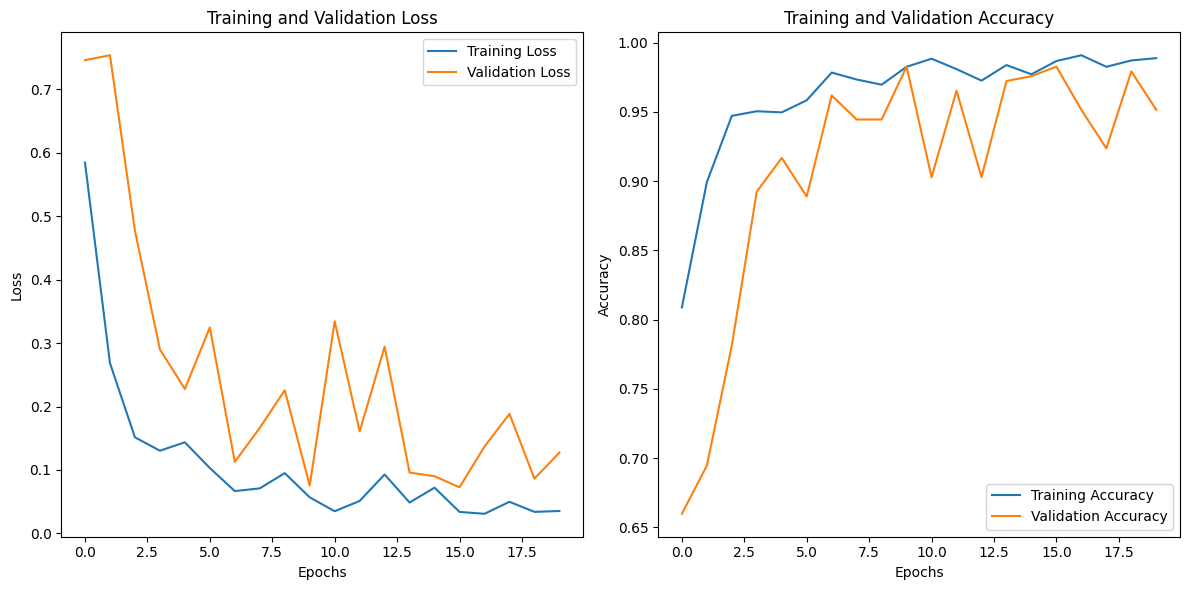

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np
import tensorflow as tf

# Function to load and evaluate the model
def load_and_evaluate_model(model_path, test_generator):
    # Load the model
    model = tf.keras.models.load_model(model_path)

    # Evaluate the model on the test data
    loss, accuracy = model.evaluate(test_generator)
    print(f'Test accuracy: {accuracy}, Test loss: {loss}')

    # Predict labels for the test data
    y_pred = model.predict(test_generator)

    # Get true labels
    y_true = test_generator.classes

    return model, y_true, y_pred

# Calculate misclassification error
def misclassification_error(y_true, y_pred):
    incorrect = np.sum(y_true != y_pred)
    total = len(y_true)
    error = incorrect / total
    return error

# Calculate misclassification rate in number
def misclassification_rate_number(misclassification_error, total_samples):
    return misclassification_error * total_samples

# Plot loss and accuracy curves
def plot_curves(history):
    plt.figure(figsize=(12, 6))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot ROC curve
def plot_roc_curve(y_true, y_pred):
    num_classes = y_pred.shape[1]
    class_labels = range(num_classes)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true.ravel(), y_pred.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    lw = 2
    plt.plot(fpr["micro"], tpr["micro"], color='darkorange',
             lw=lw, label='Micro-average ROC curve (area = {0:0.2f})'
             ''.format(roc_auc["micro"]))

    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], lw=lw, label='ROC curve of class {0} (area = {1:0.2f})'
                 ''.format(class_labels[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

# Paths
model_path = "MobileNetV2_model.h5"
test_data_directory = "test"

# Create test data generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_data_directory,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False)

# Load and evaluate the model
model, y_true, y_pred = load_and_evaluate_model(model_path, test_generator)

# Calculate misclassification error
misclassification = misclassification_error(y_true, y_pred.argmax(axis=-1))
print("Misclassification Error:", misclassification)

# Calculate misclassification rate in number
misclassification_rate = misclassification_rate_number(misclassification, len(y_true))
print("Misclassification Rate (Number):", misclassification_rate)

# Plot loss and accuracy curves
plot_curves(history)

# Plot ROC curve
def plot_roc_curve(y_true, y_pred):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    lw = 2
    plt.plot(fpr, tpr, color='darkorange',
             lw=lw, label='ROC curve (area = {0:0.2f})'.format(roc_auc))

    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()


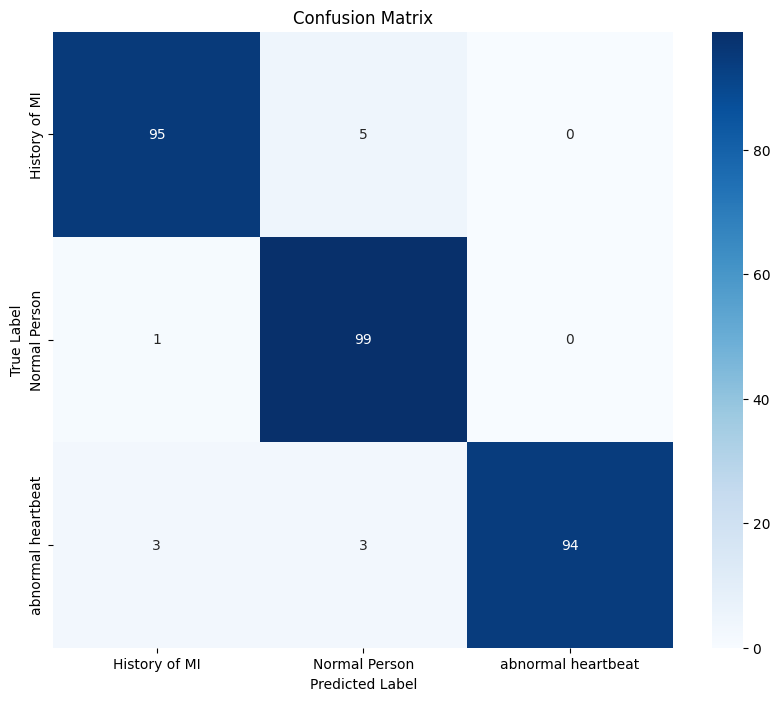

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Define class labels
class_labels = list(test_generator.class_indices.keys())

# Calculate confusion matrix with class labels
conf_matrix = confusion_matrix(y_true, y_pred.argmax(axis=-1))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths for your dataset
train_path = 'train'
test_path = 'test'
val_path = 'validation'
modelsave_path = "DenseNet201_model.h5"

# Data generators
batch_size = 32
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Shuffle is set to False for the test set
)
val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Shuffle is set to False for the validation set
)

# Import DenseNet201 model
base_model = DenseNet201(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Build custom classification model on top of DenseNet201
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dense(train_generator.num_classes, activation='softmax')
])

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(
    optimizer=Adam(lr=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
checkpoint = ModelCheckpoint(
    modelsave_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    epochs=20,
    callbacks=[checkpoint]
)

# Evaluate the model
test_loss, test_acc = model.evaluate(
    test_generator,
    steps=test_generator.samples // batch_size
)
print("Test Accuracy:", test_acc)

# Save the final model
model.save(modelsave_path)


Found 2400 images belonging to 3 classes.
Found 300 images belonging to 3 classes.
Found 300 images belonging to 3 classes.


Epoch 1/20
75/75 [==============================] - ETA: 0s - loss: 0.4984 - accuracy: 0.8375

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


75/75 [==============================] - 42s 384ms/step - loss: 0.4984 - accuracy: 0.8375 - val_loss: 0.9651 - val_accuracy: 0.5903
Epoch 2/20
75/75 [==============================] - 22s 294ms/step - loss: 0.1647 - accuracy: 0.9421 - val_loss: 0.3382 - val_accuracy: 0.8819
Epoch 3/20
75/75 [==============================] - 22s 298ms/step - loss: 0.0838 - accuracy: 0.9729 - val_loss: 0.3497 - val_accuracy: 0.8715
Epoch 4/20
75/75 [==============================] - 21s 273ms/step - loss: 0.0768 - accuracy: 0.9737 - val_loss: 0.2732 - val_accuracy: 0.9028
Epoch 5/20
75/75 [==============================] - 25s 337ms/step - loss: 0.0740 - accuracy: 0.9779 - val_loss: 0.1248 - val_accuracy: 0.9618
Epoch 6/20
75/75 [==============================] - 21s 273ms/step - loss: 0.0434 - accuracy: 0.9883 - val_loss: 1.1349 - val_accuracy: 0.7153
Epoch 7/20
75/75 [==============================] - 20s 264ms/step - loss: 0.0374 - accuracy: 0.9892 - val_loss: 0.0801 - val_accuracy: 0.9688
Epoch 8/20

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def generate_classification_report(model, test_generator):
    # Predict classes for test data
    y_pred = model.predict(test_generator)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Get true classes
    true_classes = test_generator.classes

    # Get class labels
    class_labels = list(test_generator.class_indices.keys())

    # Generate classification report
    report = classification_report(true_classes, y_pred_classes, target_names=class_labels, output_dict=True)

    # Calculate specificity
    cm = confusion_matrix(true_classes, y_pred_classes)
    num_classes = len(class_labels)
    specificity = {}
    for i in range(num_classes):
        true_negative = np.sum(np.delete(cm, i, axis=0)[:, np.delete(np.arange(num_classes), i)])
        false_positive = np.sum(cm[np.delete(np.arange(num_classes), i), i])
        specificity[class_labels[i]] = true_negative / (true_negative + false_positive)

    # Print the classification report
    print("Classification Report:")
    print(classification_report(true_classes, y_pred_classes, target_names=class_labels))
    print("\nSpecificity:")
    for class_label, spec in specificity.items():
        print(f"{class_label}: {spec:.4f}")

# Load the saved model
loaded_model = tf.keras.models.load_model("DenseNet201_model.h5")

# Generate classification report
generate_classification_report(loaded_model, test_generator)


10/10 [==============================] - 11s 709ms/step
Classification Report:
                    precision    recall  f1-score   support

     History of MI       0.99      0.98      0.98       100
     Normal Person       1.00      0.95      0.97       100
abnormal heartbeat       0.93      0.99      0.96       100

          accuracy                           0.97       300
         macro avg       0.97      0.97      0.97       300
      weighted avg       0.97      0.97      0.97       300


Specificity:
History of MI: 0.9950
Normal Person: 1.0000
abnormal heartbeat: 0.9650


Found 300 images belonging to 3 classes.
10/10 [==============================] - 5s 180ms/step - loss: 0.0828 - accuracy: 0.9733
Test accuracy: 0.9733333587646484, Test loss: 0.08276161551475525
10/10 [==============================] - 6s 289ms/step
Misclassification Error: 0.02666666666666667
Misclassification Rate (Number): 8.0


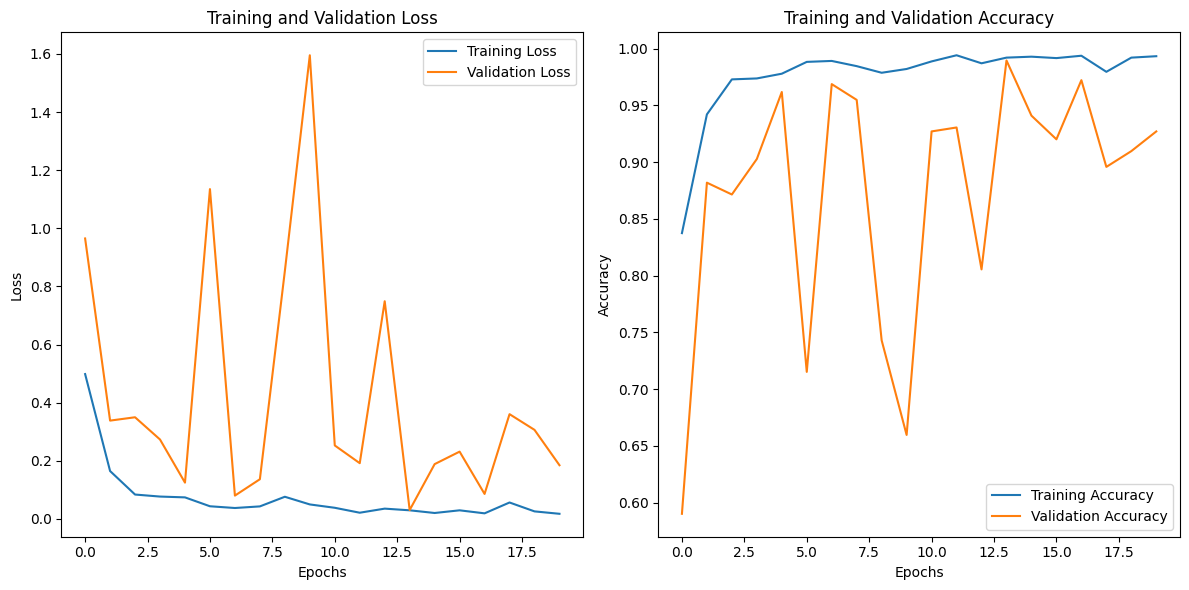

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np
import tensorflow as tf

# Function to load and evaluate the model
def load_and_evaluate_model(model_path, test_generator):
    # Load the model
    model = tf.keras.models.load_model(model_path)

    # Evaluate the model on the test data
    loss, accuracy = model.evaluate(test_generator)
    print(f'Test accuracy: {accuracy}, Test loss: {loss}')

    # Predict labels for the test data
    y_pred = model.predict(test_generator)

    # Get true labels
    y_true = test_generator.classes

    return model, y_true, y_pred

# Calculate misclassification error
def misclassification_error(y_true, y_pred):
    incorrect = np.sum(y_true != y_pred)
    total = len(y_true)
    error = incorrect / total
    return error

# Calculate misclassification rate in number
def misclassification_rate_number(misclassification_error, total_samples):
    return misclassification_error * total_samples

# Plot loss and accuracy curves
def plot_curves(history):
    plt.figure(figsize=(12, 6))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot ROC curve
def plot_roc_curve(y_true, y_pred):
    num_classes = y_pred.shape[1]
    class_labels = range(num_classes)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true.ravel(), y_pred.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    lw = 2
    plt.plot(fpr["micro"], tpr["micro"], color='darkorange',
             lw=lw, label='Micro-average ROC curve (area = {0:0.2f})'
             ''.format(roc_auc["micro"]))

    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], lw=lw, label='ROC curve of class {0} (area = {1:0.2f})'
                 ''.format(class_labels[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

# Paths
model_path = "DenseNet201_model.h5"
test_data_directory = "test"

# Create test data generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_data_directory,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False)

# Load and evaluate the model
model, y_true, y_pred = load_and_evaluate_model(model_path, test_generator)

# Calculate misclassification error
misclassification = misclassification_error(y_true, y_pred.argmax(axis=-1))
print("Misclassification Error:", misclassification)

# Calculate misclassification rate in number
misclassification_rate = misclassification_rate_number(misclassification, len(y_true))
print("Misclassification Rate (Number):", misclassification_rate)

# Plot loss and accuracy curves
plot_curves(history)

# Plot ROC curve
def plot_roc_curve(y_true, y_pred):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    lw = 2
    plt.plot(fpr, tpr, color='darkorange',
             lw=lw, label='ROC curve (area = {0:0.2f})'.format(roc_auc))

    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()


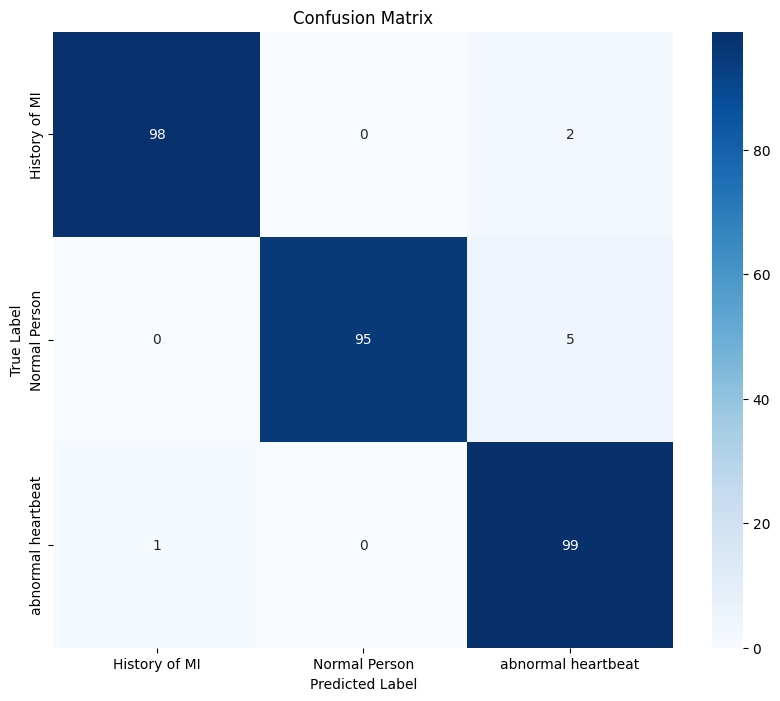

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Define class labels
class_labels = list(test_generator.class_indices.keys())

# Calculate confusion matrix with class labels
conf_matrix = confusion_matrix(y_true, y_pred.argmax(axis=-1))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define paths for your dataset
train_path = 'train'
test_path = 'test'
val_path = 'validation'
modelsave_path = "ResNet50_model.h5"

# Data generators
batch_size = 32
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical'
)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Shuffle is set to False for the test set
)
val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # Shuffle is set to False for the validation set
)

# Import ResNet50 model
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Build custom classification model on top of ResNet50
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dense(train_generator.num_classes, activation='softmax')
])

# Freeze pretrained layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the model
model.compile(
    optimizer=Adam(lr=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
checkpoint = ModelCheckpoint(
    modelsave_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    epochs=20,
    callbacks=[checkpoint]
)

# Evaluate the model
test_loss, test_acc = model.evaluate(
    test_generator,
    steps=test_generator.samples // batch_size
)
print("Test Accuracy:", test_acc)

# Save the final model
model.save(modelsave_path)


Found 2400 images belonging to 3 classes.
Found 300 images belonging to 3 classes.
Found 300 images belonging to 3 classes.
94765736/94765736 [==============================] - 0s 0us/step


Epoch 1/20
75/75 [==============================] - ETA: 0s - loss: 0.8572 - accuracy: 0.6675

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


75/75 [==============================] - 26s 262ms/step - loss: 0.8572 - accuracy: 0.6675 - val_loss: 1.2557 - val_accuracy: 0.3472
Epoch 2/20
75/75 [==============================] - 17s 230ms/step - loss: 0.5550 - accuracy: 0.7675 - val_loss: 1.8457 - val_accuracy: 0.3646
Epoch 3/20
75/75 [==============================] - 17s 221ms/step - loss: 0.4950 - accuracy: 0.8021 - val_loss: 2.9266 - val_accuracy: 0.3472
Epoch 4/20
75/75 [==============================] - 17s 220ms/step - loss: 0.3664 - accuracy: 0.8508 - val_loss: 2.1275 - val_accuracy: 0.3542
Epoch 5/20
75/75 [==============================] - 18s 241ms/step - loss: 0.4034 - accuracy: 0.8375 - val_loss: 4.6567 - val_accuracy: 0.3021
Epoch 6/20
75/75 [==============================] - 17s 229ms/step - loss: 0.2901 - accuracy: 0.8892 - val_loss: 2.6209 - val_accuracy: 0.5868
Epoch 7/20
75/75 [==============================] - 17s 221ms/step - loss: 0.2278 - accuracy: 0.9154 - val_loss: 8.4454 - val_accuracy: 0.3507
Epoch 8/20

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def generate_classification_report(model, test_generator):
    # Predict classes for test data
    y_pred = model.predict(test_generator)
    y_pred_classes = np.argmax(y_pred, axis=1)

    # Get true classes
    true_classes = test_generator.classes

    # Get class labels
    class_labels = list(test_generator.class_indices.keys())

    # Generate classification report
    report = classification_report(true_classes, y_pred_classes, target_names=class_labels, output_dict=True)

    # Calculate specificity
    cm = confusion_matrix(true_classes, y_pred_classes)
    num_classes = len(class_labels)
    specificity = {}
    for i in range(num_classes):
        true_negative = np.sum(np.delete(cm, i, axis=0)[:, np.delete(np.arange(num_classes), i)])
        false_positive = np.sum(cm[np.delete(np.arange(num_classes), i), i])
        specificity[class_labels[i]] = true_negative / (true_negative + false_positive)

    # Print the classification report
    print("Classification Report:")
    print(classification_report(true_classes, y_pred_classes, target_names=class_labels))
    print("\nSpecificity:")
    for class_label, spec in specificity.items():
        print(f"{class_label}: {spec:.4f}")

# Load the saved model
loaded_model = tf.keras.models.load_model("ResNet50_model.h5")

# Generate classification report
generate_classification_report(loaded_model, test_generator)


10/10 [==============================] - 4s 210ms/step
Classification Report:
                    precision    recall  f1-score   support

     History of MI       0.38      1.00      0.55       100
     Normal Person       1.00      0.01      0.02       100
abnormal heartbeat       0.94      0.32      0.48       100

          accuracy                           0.44       300
         macro avg       0.77      0.44      0.35       300
      weighted avg       0.77      0.44      0.35       300


Specificity:
History of MI: 0.1750
Normal Person: 1.0000
abnormal heartbeat: 0.9900


Found 300 images belonging to 3 classes.
10/10 [==============================] - 4s 310ms/step - loss: 8.5615 - accuracy: 0.4433
Test accuracy: 0.44333332777023315, Test loss: 8.561532020568848
10/10 [==============================] - 4s 175ms/step
Misclassification Error: 0.5566666666666666
Misclassification Rate (Number): 167.0


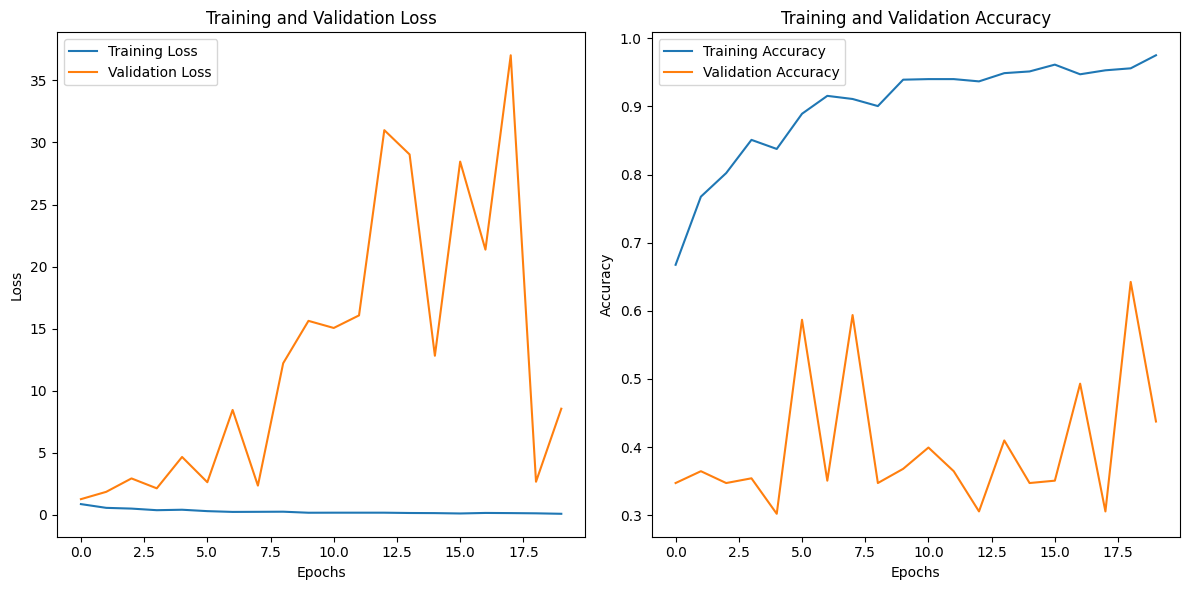

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np
import tensorflow as tf

# Function to load and evaluate the model
def load_and_evaluate_model(model_path, test_generator):
    # Load the model
    model = tf.keras.models.load_model(model_path)

    # Evaluate the model on the test data
    loss, accuracy = model.evaluate(test_generator)
    print(f'Test accuracy: {accuracy}, Test loss: {loss}')

    # Predict labels for the test data
    y_pred = model.predict(test_generator)

    # Get true labels
    y_true = test_generator.classes

    return model, y_true, y_pred

# Calculate misclassification error
def misclassification_error(y_true, y_pred):
    incorrect = np.sum(y_true != y_pred)
    total = len(y_true)
    error = incorrect / total
    return error

# Calculate misclassification rate in number
def misclassification_rate_number(misclassification_error, total_samples):
    return misclassification_error * total_samples

# Plot loss and accuracy curves
def plot_curves(history):
    plt.figure(figsize=(12, 6))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot ROC curve
def plot_roc_curve(y_true, y_pred):
    num_classes = y_pred.shape[1]
    class_labels = range(num_classes)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true.ravel(), y_pred.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    lw = 2
    plt.plot(fpr["micro"], tpr["micro"], color='darkorange',
             lw=lw, label='Micro-average ROC curve (area = {0:0.2f})'
             ''.format(roc_auc["micro"]))

    for i in range(num_classes):
        plt.plot(fpr[i], tpr[i], lw=lw, label='ROC curve of class {0} (area = {1:0.2f})'
                 ''.format(class_labels[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

# Paths
model_path = "ResNet50_model.h5"
test_data_directory = "test"

# Create test data generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_data_directory,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False)

# Load and evaluate the model
model, y_true, y_pred = load_and_evaluate_model(model_path, test_generator)

# Calculate misclassification error
misclassification = misclassification_error(y_true, y_pred.argmax(axis=-1))
print("Misclassification Error:", misclassification)

# Calculate misclassification rate in number
misclassification_rate = misclassification_rate_number(misclassification, len(y_true))
print("Misclassification Rate (Number):", misclassification_rate)

# Plot loss and accuracy curves
plot_curves(history)

# Plot ROC curve
def plot_roc_curve(y_true, y_pred):
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    lw = 2
    plt.plot(fpr, tpr, color='darkorange',
             lw=lw, label='ROC curve (area = {0:0.2f})'.format(roc_auc))

    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()


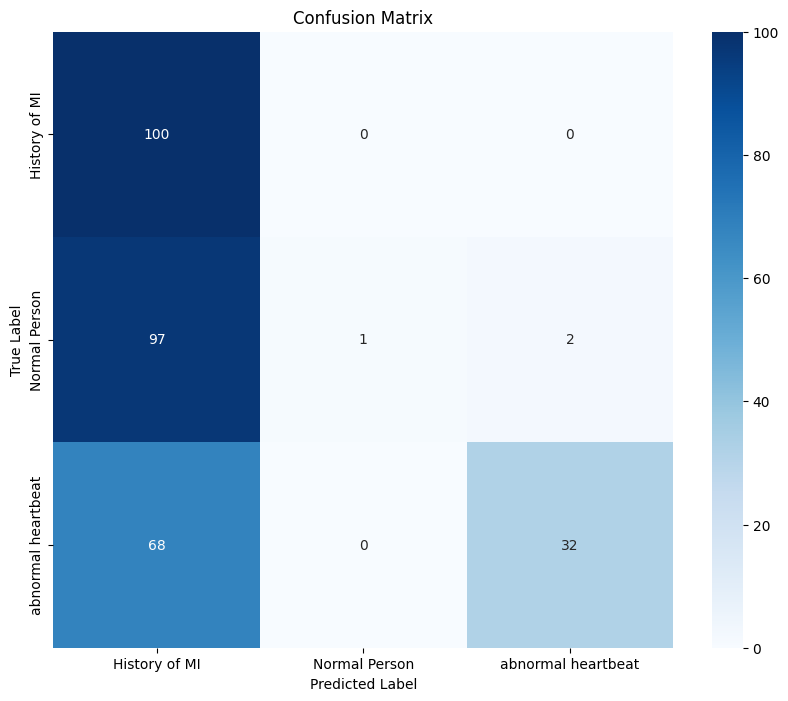

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Define class labels
class_labels = list(test_generator.class_indices.keys())

# Calculate confusion matrix with class labels
conf_matrix = confusion_matrix(y_true, y_pred.argmax(axis=-1))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


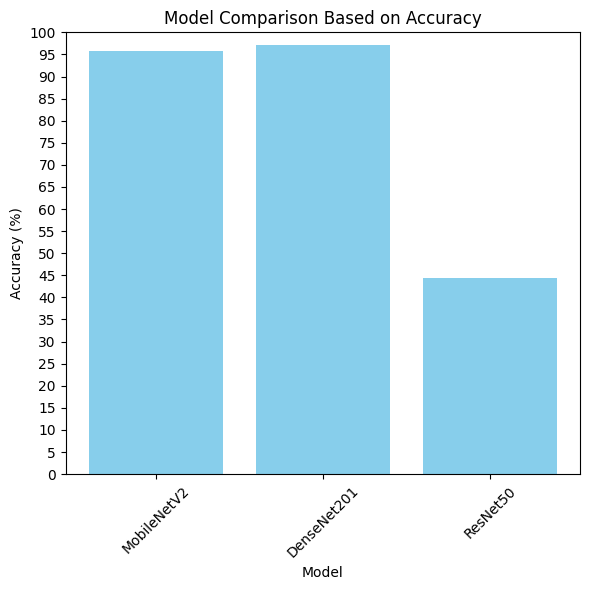

In [ ]:
import matplotlib.pyplot as plt

# Model names and corresponding accuracy
models = ['MobileNetV2', 'DenseNet201', 'ResNet50']
accuracy = [95.83, 97.22, 44.33]  # Example accuracy values

# Plotting the graph
plt.figure(figsize=(6, 6))
plt.bar(models, accuracy, color='skyblue')

# Adding titles and labels
plt.title('Model Comparison Based on Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')

# Setting y-axis limits
plt.ylim(0, 100)  # Setting the range from 0 to 100

# Setting y-axis scale with increments of 5
plt.yticks(range(0, 101, 5))

# Rotating x-axis labels for better readability
plt.xticks(rotation=45)

# Displaying the graph
plt.tight_layout()
plt.show()